# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [3]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

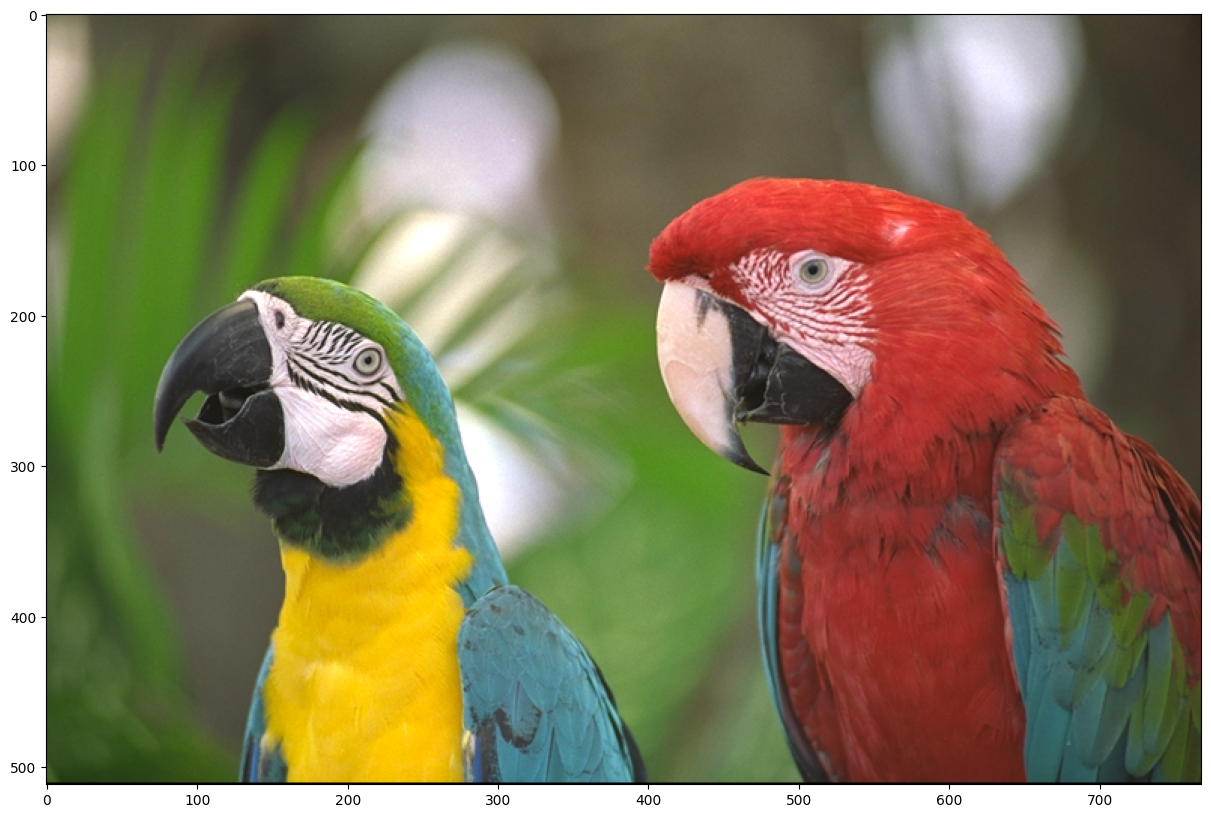

In [4]:
# Load image
img = cv2.imread('../data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [5]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [17]:
def quantize_image(img, palette):
    rows, cols, _ = img.shape
    img = img.astype(np.float32)
    palette = palette.astype(np.float32)
    quantized = np.zeros_like(img)

    for r in range(rows):
        for c in range(cols):
            # Extract the original pixel value
            pixel = img[r, c, :]

            # Find the closest colour from the pallette
            diffs = palette - pixel[None, :]
            distances = np.linalg.norm(diffs, axis=1)
            idx = np.argmin(distances)
            new_pixel = palette[idx]
            
            # Apply quantization
            quantized[r, c, :] = new_pixel

    return quantized.astype(np.uint8)

In [18]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = quantize_image(img, colors)

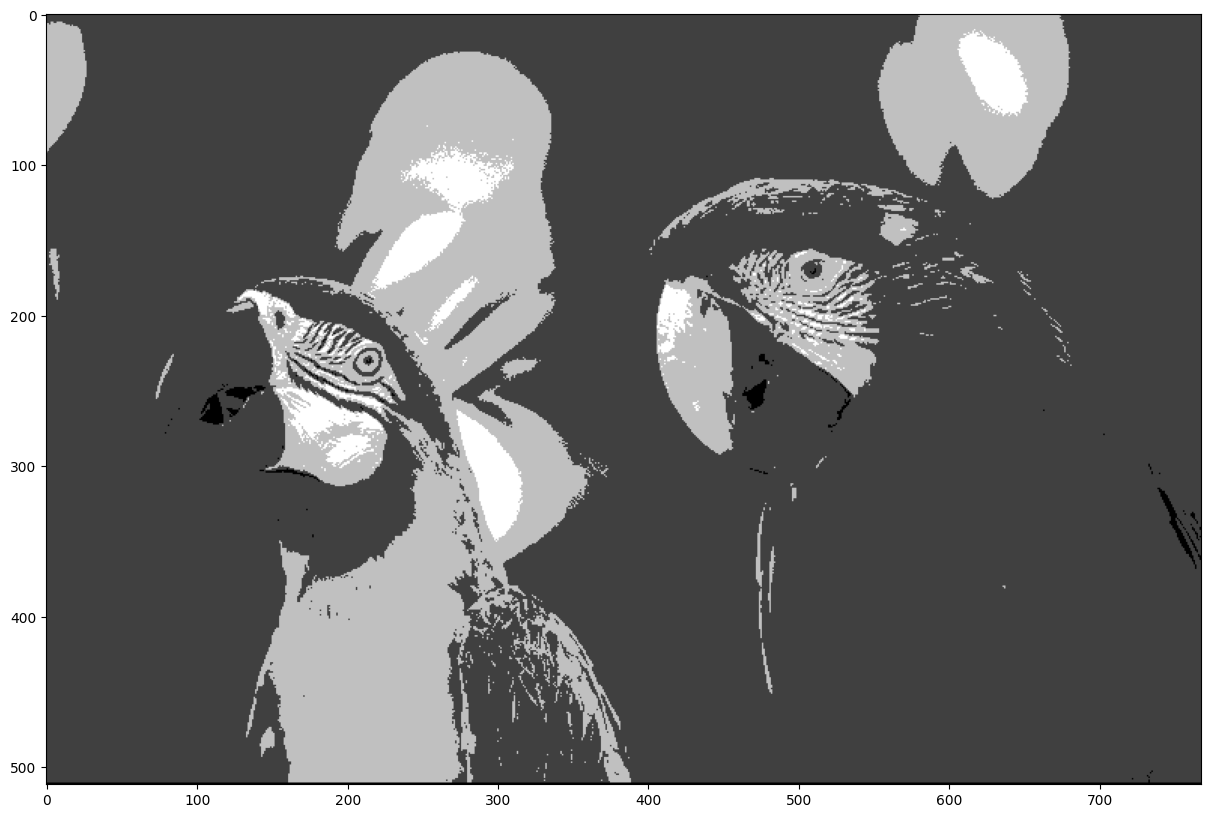

In [19]:
# Show quantized image (don't forget to cast back to uint8)
quantized = quantized.astype(np.uint8)
plt.imshow(quantized)

In [26]:
def quantization_error(img, result):
    img = img.astype(np.float32)
    result = result.astype(np.float32)
    return np.mean(np.linalg.norm(img - result, axis=2))


In [ ]:
# Compute average quantization error
print(quantization_error(img, quantized))

67.73236


#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [ ]:
def floyd_steinberg_dither(img, palette):
    rows, cols, _ = img.shape
    img_f = img.astype(np.float32).copy()
    palette = palette.astype(np.float32)
    dithering = np.zeros_like(img_f)

    for r in range(1, rows-1):
        for c in range(1, cols-1):
            # Extract the original pixel value
            pixel = img_f[r, c, :]

            # Find the closest colour from the pallette
            diffs = palette - pixel[None, :]
            distances = np.linalg.norm(diffs, axis=1)
            new_pixel = palette[np.argmin(distances)]

            # Compute quantization error
            quant_error = pixel - new_pixel

            # Diffuse the quantization error accroding to the FS diffusion matrix
            img_f[r,   c+1, :] += (7/16.0) * quant_error
            img_f[r+1, c-1, :] += (3/16.0) * quant_error
            img_f[r+1, c,   :] += (5/16.0) * quant_error
            img_f[r+1, c+1, :] += (1/16.0) * quant_error

            img_f[r-1:r+2, c-1:c+2, :] = np.clip(img_f[r-1:r+2, c-1:c+2, :], 0, 255)

            # Apply dithering
            dithering[r, c, :] = new_pixel

    # Casting back to uint8
    return dithering.astype(np.uint8)

In [10]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img).astype(np.float32)
palette = colors.astype(np.float32)
dithering = floyd_steinberg_dither(img, palette)

(<Axes: >, <matplotlib.image.AxesImage at 0x27bef0e7ed0>)

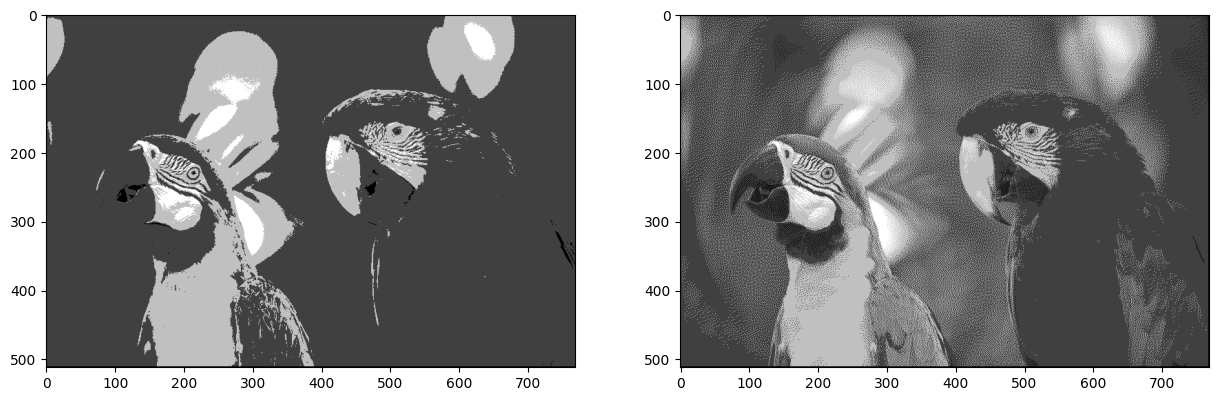

In [14]:
# Show quantized image
plt.subplot(121), plt.imshow(quantized)   # optimally quantized
plt.subplot(122), plt.imshow(dithering)   # dithering

In [28]:
# Compute average quantization error for dithered image
print(quantization_error(img, dithering))

80.74153


### Questions
#### Which image has higher quantization error? Optimally quantized or dithered?
Dithered. This is expected, as this process sometimes picks a farther palette color to shape local texture.
#### Which image looks better to you?
Dithered. It has visually smoother tones, and this result is expected.
#### Can you repeat the same process using only two colours: black and white? Show me :-)
The result in the cell below

(<Axes: >, <matplotlib.image.AxesImage at 0x27beff48d90>)

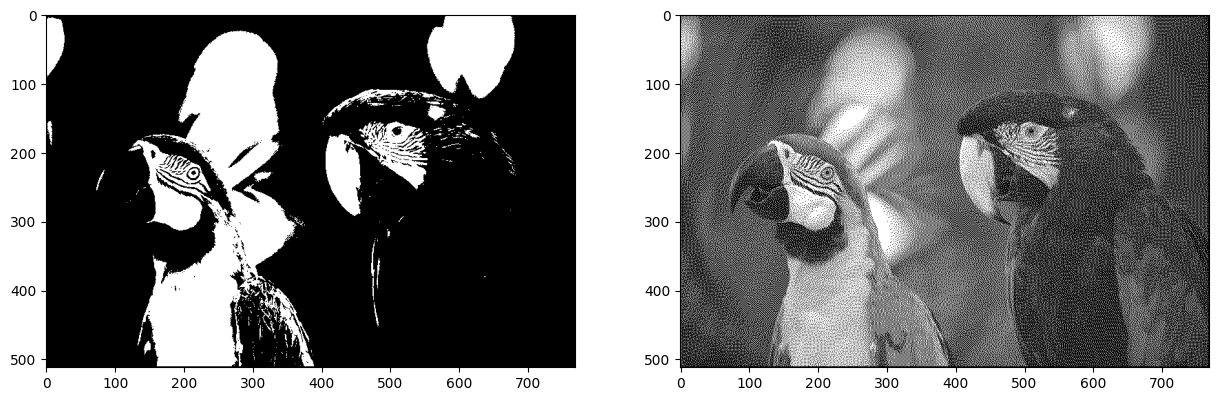

In [21]:
palette_bw = np.array([[0,0,0], [255,255,255]])

quantized_bw = quantize_image(img, palette_bw)
dithered_bw = floyd_steinberg_dither(img, palette_bw)

plt.subplot(121), plt.imshow(quantized_bw)
plt.subplot(122), plt.imshow(dithered_bw)

In [29]:
print(quantization_error(img, quantized_bw))
print(quantization_error(img, dithered_bw))

152.54225
192.33665


### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

In [34]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=256).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_

(<Axes: >, <matplotlib.image.AxesImage at 0x27b9dceea90>)

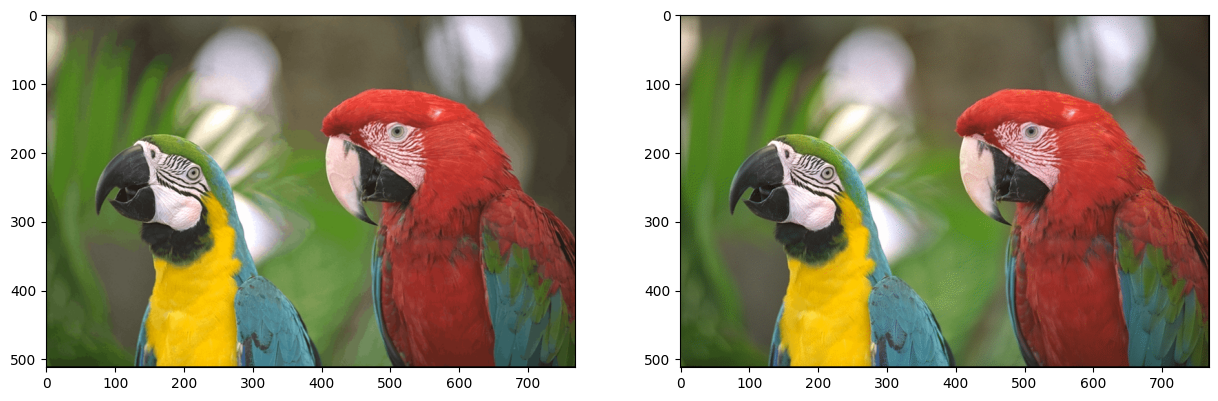

In [35]:
plt.subplot(121), plt.imshow(quantize_image(img, colors))
plt.subplot(122), plt.imshow(floyd_steinberg_dither(img, colors))

Apply FS dithering the same way you did before.
### How does the result look like to you?
Looks like a painting or poster. Big flat areas of color, some banding in the background, details are lost.
### What happens if we use 32 colours?
Much smoother, the background and feathers have more natural shades.
### And what happens if we use 256 colours?
Very close to the original photo, though there is some difference. For example, on the left one (optimally quantized), the leaves are still like on a painting.